# Demo 1: CLIP Embeddings + Similarity Search
# Using OpenCLIP for NVIDIA Certified Gen AI Multimodal Course

In this notebook, we'll:
1. Install and import necessary libraries
2. Load an OpenCLIP model and preprocessing transforms
3. Prepare a small image dataset
4. Compute image embeddings
5. Compute text embeddings
6. Perform similarity search (text-to-image and image-to-image)
7. Visualize the top-K similar results

---

# Install dependencies

In [ ]:
# Run this cell once to install required packages
!pip install torch torchvision open_clip_torch ftfy regex tqdm scikit-learn pillow

In [ ]:
!wget https://raw.githubusercontent.com/manifoldailearning/NVIDIA-Certified-Generative-AI-MultiModal-NCA-GENM/refs/heads/main/images/images_v1.zip
!unzip -q "images_v1.zip"

# Import libraries

In [ ]:
import os
import torch
import open_clip
from PIL import Image
from torchvision import transforms
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

model_name = 'ViT-B-32'
pretrained = 'laion2b_s34b_b79k'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
model.to(device).eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

# Prepare a sample image dataset

In [ ]:
# Create a folder `data/images/` and add a few sample JPEG/PNG images.
image_folder = 'data/images'
image_paths = [os.path.join(image_folder, fname) for fname in os.listdir(image_folder)
               if fname.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Found {len(image_paths)} images in '{image_folder}'")

Found 30 images in 'data/images'


# Compute image embeddings

In [ ]:

# Preprocess and batch images, then compute embeddings
image_tensors = []
for path in image_paths:
    img = Image.open(path).convert('RGB')
    tensor = preprocess(img)
    image_tensors.append(tensor)

images_batch = torch.stack(image_tensors).to(device)
with torch.no_grad():
    image_embeddings = model.encode_image(images_batch)
    # Normalize embeddings
    image_embeddings /= image_embeddings.norm(dim=-1, keepdim=True)

# Move to CPU
image_embeddings = image_embeddings.cpu().numpy()

# Compute text embeddings

In [ ]:

# Preprocess and batch images, then compute embeddings
image_tensors = []
for path in image_paths:
    img = Image.open(path).convert('RGB')
    tensor = preprocess(img)
    image_tensors.append(tensor)

images_batch = torch.stack(image_tensors).to(device)
with torch.no_grad():
    image_embeddings = model.encode_image(images_batch)
    # Normalize embeddings
    image_embeddings /= image_embeddings.norm(dim=-1, keepdim=True)

# Move to CPU
image_embeddings = image_embeddings.cpu().numpy()


In [ ]:
# Define some text queries
text_queries = [
    "a photo of a cat",
    "a scenic mountain landscape",
    "a delicious plate of food"
]

# Tokenize and encode
text_tokens = open_clip.tokenize(text_queries)
with torch.no_grad():
    text_emb = model.encode_text(text_tokens.to(device))
    text_emb /= text_emb.norm(dim=-1, keepdim=True)
text_embeddings = text_emb.cpu().numpy()

# Text-to-Image Similarity Search

Query: 'a photo of a cat' -> Top-3 Images:


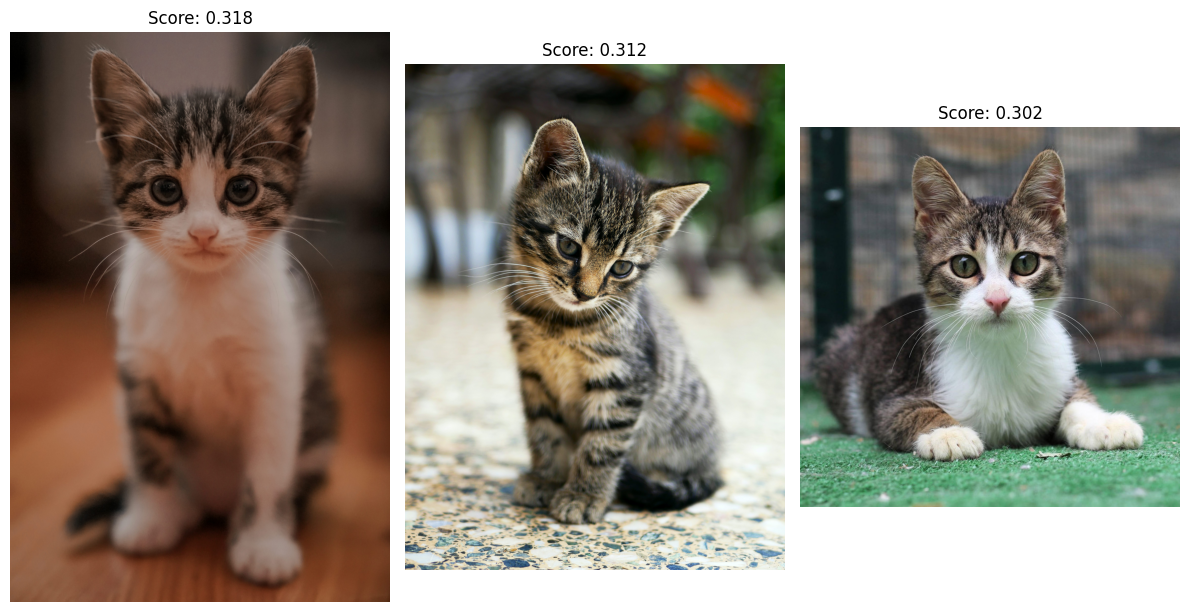

Query: 'a scenic mountain landscape' -> Top-3 Images:


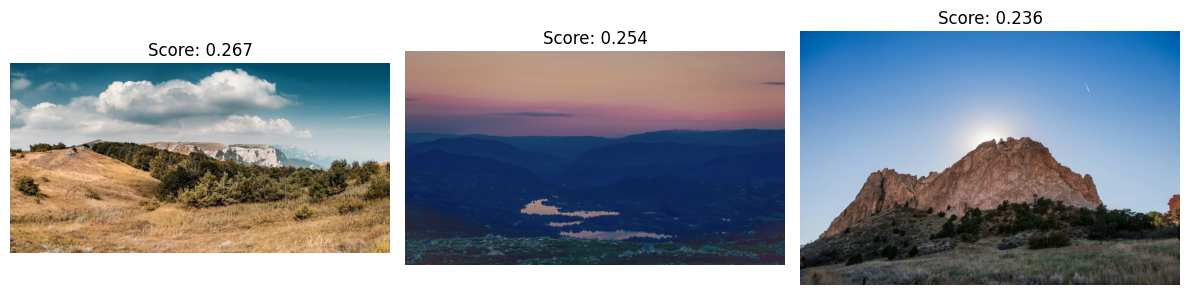

Query: 'a delicious plate of food' -> Top-3 Images:


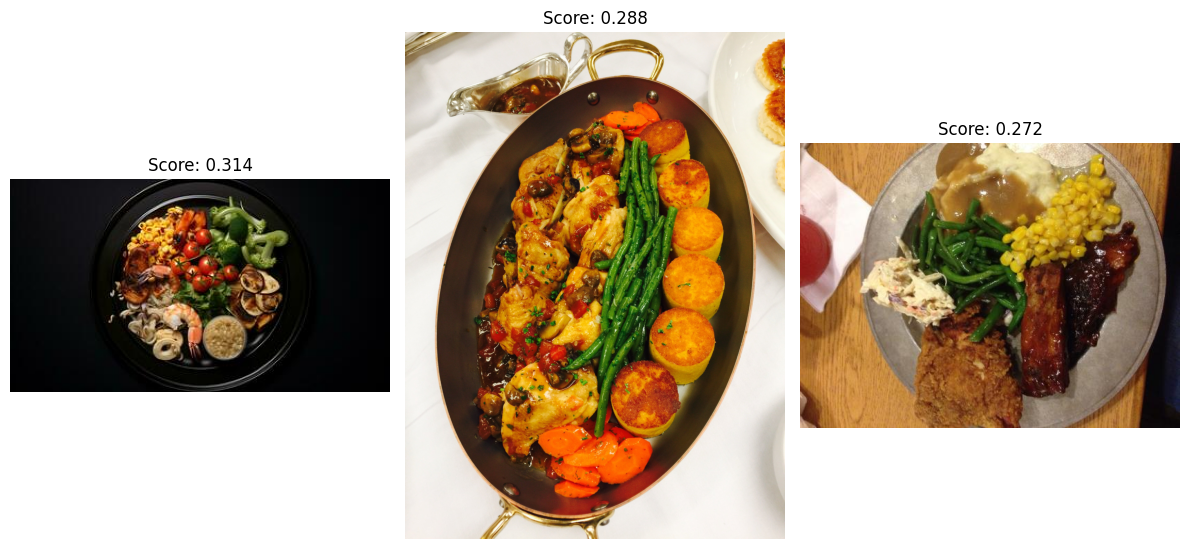

In [ ]:
def show_images(paths, titles=None, cols=3, figsize=(12, 8)):
    rows = (len(paths) + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, path in enumerate(paths):
        img = Image.open(path).convert('RGB')
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis('off')
        if titles:
            plt.title(titles[i])
    plt.tight_layout()
    plt.show()

# For each text query, find top-3 matching images
for idx, query in enumerate(text_queries):
    sims = cosine_similarity([text_embeddings[idx]], image_embeddings)[0]
    topk = sims.argsort()[-3:][::-1]
    print(f"Query: '{query}' -> Top-3 Images:")
    show_images([image_paths[i] for i in topk],
                titles=[f"Score: {sims[i]:.3f}" for i in topk])

# Image-to-Image Similarity Search

Reference Image: data/images/cat3.jpeg


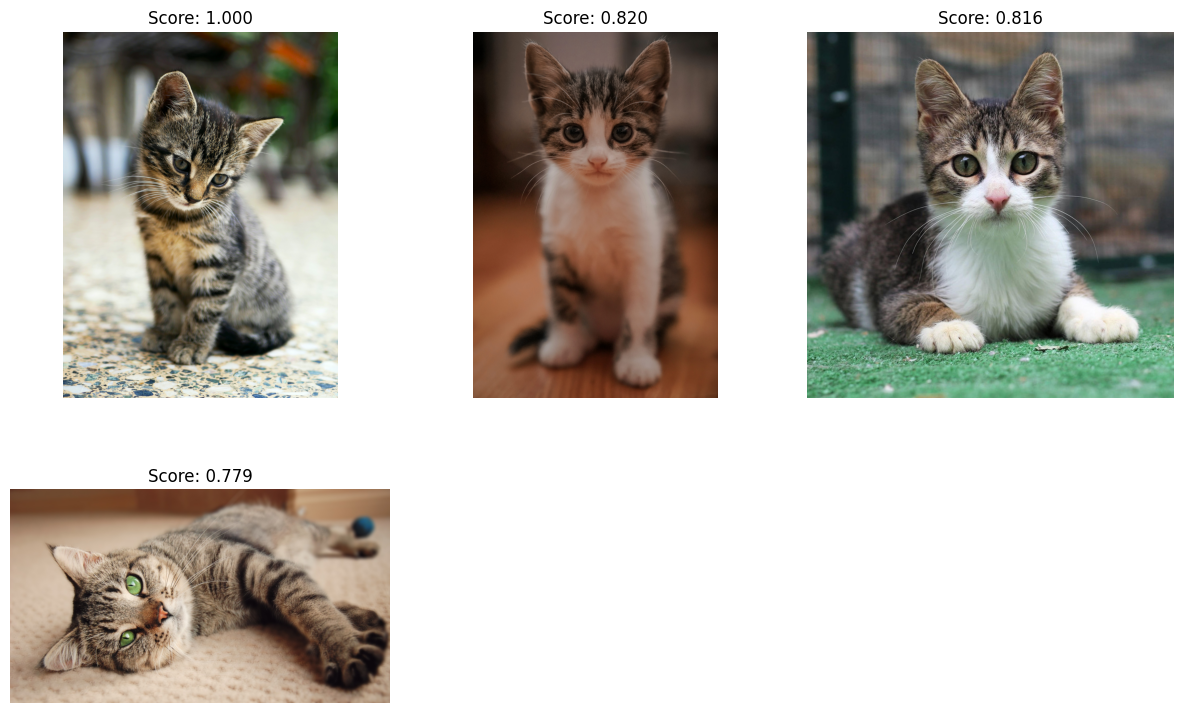

In [ ]:
# Pick a reference image (first one)
ref_idx = 1
ref_emb = image_embeddings[ref_idx:ref_idx+1]

# Compute similarity against all
sims_img = cosine_similarity(ref_emb, image_embeddings)[0]
topk_img = sims_img.argsort()[-4:][::-1]  # include itself plus top-3

print(f"Reference Image: {image_paths[ref_idx]}")
show_images([image_paths[i] for i in topk_img],
            titles=[f"Score: {sims_img[i]:.3f}" for i in topk_img])